# 13h — Structural Stochastic LGD under a Climate Factor

Source scripts: `chap13_credit15a.m`, `chap13_credit15b.m`, `chap13_credit15c.m`.

Loss-given-default (LGD) is usually treated as a fixed parameter, but the
**Frye-Pykhtin structural stochastic-LGD model** ties recovery to the same
systematic factor that drives default, so LGD becomes *conditionally*
higher in bad states of the world (the well-known empirical PD/LGD
correlation). This notebook builds the model, then shows an equivalent
**Vasicek-form reparametrization** that is more convenient when only an
*exogenous* unconditional LGD (rather than the structural `mu_i`/`sigma_i`
recovery parameters) is available — the same "cumulative-probability →
Gaussian-copula conditioning" idea used for the default probabilities in
`13g`, here applied to the recovery/loss side instead.

- **`credit15a`**: the structural model directly. An obligor's normalized
  recovery draw is `mu_i + sigma_i * Z`, `Z ~ N(0,1)`; the unconditional
  `LGD = 1 - Φ(mu_i / √(1+σ_i²))` follows from integrating out `Z`.
  Conditioning `Z` on a systematic climate factor
  `Z = √ρ·X + √(1-ρ)·ε` gives the conditional
  `LGD(X) = 1 - Φ((mu_i + σ_i√ρ·X) / √(1 + σ_i²(1-ρ)))`, swept across
  `X ∈ {-3,...,3}` at `ρ=0.20`.
- **`credit15b`**: compares that structural conditional LGD against a
  **Vasicek-form** reparametrization that starts from an assumed
  *unconditional* `LGD=50%` (not derived from `mu_i`/`sigma_i`) and applies
  the same single-factor Gaussian-copula conditioning used for PDs:
  `LGD(X) = Φ((Φ⁻¹(LGD) - √ρ·X)/√(1-ρ))`.
- **`credit15c`**: tabulates the Vasicek-form LGD across a `(ρ, X)` grid
  (4 correlation levels × 7 factor values), still at the assumed `LGD=50%`.

No missing functions and no data files — `Φ`/`Φ⁻¹` are
`scipy.stats.norm.cdf`/`.ppf`, the same pattern used throughout this
chapter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

color_blue = "#1f77b4"
color_red  = "#d62728"
color_black = "#000000"

plt.rcParams["figure.dpi"] = 100

## `credit15a` — Structural stochastic LGD

Unconditional LGD, then the conditional LGD swept across `X_climate`
at fixed `ρ=0.20`.

In [2]:
rho_climate = 0.20
X_climate = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=float)

mu_i, sigma_i = 0.10, 0.50

LGD_unconditional = 1 - norm.cdf(mu_i / np.sqrt(1 + sigma_i**2))
print(f"Unconditional structural LGD: {LGD_unconditional:.4%}")

LGD_climate_15a = 1 - norm.cdf(
    (mu_i + sigma_i * np.sqrt(rho_climate) * X_climate)
    / np.sqrt(1 + sigma_i**2 * (1 - rho_climate))
)

df_15a = pd.DataFrame({"X": X_climate, "Conditional LGD (%)": 100 * LGD_climate_15a})
df_15a

Unconditional structural LGD: 46.4365%


,X,Conditional LGD (%)
0,-3.0,69.884634
1,-2.0,62.436348
2,-1.0,54.492013
3,0.0,46.363224
4,1.0,38.383987
5,2.0,30.870113
6,3.0,24.082241


In [3]:
monotone_decreasing_15a = np.all(np.diff(LGD_climate_15a) <= 1e-12)
print("Conditional LGD monotonically decreasing in X (higher X = better recovery draw):", bool(monotone_decreasing_15a))

# Note: LGD(X=0) is close to, but does not exactly equal, the unconditional LGD.
# This is expected, not a bug: conditioning on the factor also shrinks the residual
# variance of the recovery score from sigma_i^2 to sigma_i^2*(1-rho), so the X=0
# "average factor" slice is not the same integral as the unconditional (factor-marginalized)
# distribution. The Vasicek-form reparametrization below is built differently and does
# recover X=0 == the assumed unconditional value exactly (see credit15b).
print(f"LGD(X=0) = {100*LGD_climate_15a[3]:.2f}%  vs. unconditional LGD = {100*LGD_unconditional:.2f}%  "
      f"(close but not equal -- conditioning also shrinks the residual variance, see note above)")

Conditional LGD monotonically decreasing in X (higher X = better recovery draw): True
LGD(X=0) = 46.36%  vs. unconditional LGD = 46.44%  (close but not equal -- conditioning also shrinks the residual variance, see note above)


## `credit15b` — Structural vs. Vasicek-form comparison

The source script recomputes the same structural `LGD_climate1` from
`credit15a`, then builds a second curve `LGD_climate2` starting from an
**assumed exogenous unconditional `LGD=50%`** (not derived from
`mu_i`/`sigma_i`) and applying the Vasicek-form single-factor conditioning.

Note the two curves start from *different* unconditional levels: the
structural model's own unconditional LGD (computed above) is
~46.4%, not exactly the 50% assumed for the Vasicek-form curve — the
source script juxtaposes two distinct LGD specifications (one derived
from recovery-draw parameters, one assumed outright) rather than two
parametrizations of the *same* number. Both curves are reproduced
faithfully as given; the comparison is about the *shape* of climate
sensitivity each form produces, not about the two curves coinciding.

In [4]:
LGD_exogenous = 0.50

LGD1 = LGD_unconditional  # same structural unconditional LGD as credit15a
LGD_climate1 = LGD_climate_15a  # same structural conditional curve as credit15a

LGD2 = LGD_exogenous
LGD_climate2 = norm.cdf((norm.ppf(LGD_exogenous) - np.sqrt(rho_climate) * X_climate) / np.sqrt(1 - rho_climate))

df_15b = pd.DataFrame({
    "X": X_climate,
    "Structural LGD_climate1 (%)": 100 * LGD_climate1,
    "Vasicek-form LGD_climate2 (%)": 100 * LGD_climate2,
})
df_15b

,X,Structural LGD_climate1 (%),Vasicek-form LGD_climate2 (%)
0,-3.0,69.884634,93.319280
1,-2.0,62.436348,84.134475
2,-1.0,54.492013,69.146246
3,0.0,46.363224,50.000000
4,1.0,38.383987,30.853754
5,2.0,30.870113,15.865525
6,3.0,24.082241,6.680720


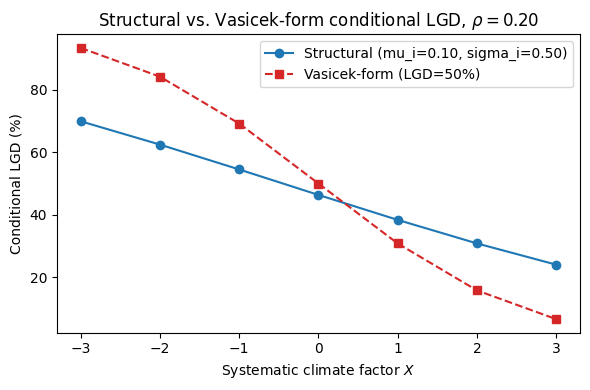

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(X_climate, 100 * LGD_climate1, "o-", color=color_blue, linewidth=1.5, label="Structural (mu_i=0.10, sigma_i=0.50)")
ax.plot(X_climate, 100 * LGD_climate2, "s--", color=color_red, linewidth=1.5, label="Vasicek-form (LGD=50%)")
ax.set_xlabel("Systematic climate factor $X$")
ax.set_ylabel("Conditional LGD (%)")
ax.set_title(r"Structural vs. Vasicek-form conditional LGD, $\rho=0.20$")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
monotone_decreasing_2 = np.all(np.diff(LGD_climate2) <= 1e-12)
print("Vasicek-form conditional LGD also monotonically decreasing in X:", bool(monotone_decreasing_2))
print(f"At X=0, Vasicek-form LGD ({100*LGD_climate2[3]:.2f}%) equals the assumed unconditional LGD ({100*LGD_exogenous:.2f}%) — check:",
      np.isclose(LGD_climate2[3], LGD_exogenous))
print(f"Both curves span roughly the same range even though their unconditional levels differ "
      f"(structural: {100*LGD_climate1.min():.1f}-{100*LGD_climate1.max():.1f}%, "
      f"Vasicek: {100*LGD_climate2.min():.1f}-{100*LGD_climate2.max():.1f}%)")

Vasicek-form conditional LGD also monotonically decreasing in X: True
At X=0, Vasicek-form LGD (50.00%) equals the assumed unconditional LGD (50.00%) — check: True
Both curves span roughly the same range even though their unconditional levels differ (structural: 24.1-69.9%, Vasicek: 6.7-93.3%)


## `credit15c` — Vasicek-form LGD across a correlation × factor grid

Same Vasicek-form conditioning as `credit15b`'s `LGD_climate2`, at the
assumed `LGD=50%`, tabulated across 4 correlation levels
(`ρ ∈ {0, 0.10, 0.20, 0.30}`) and the same 7-point `X_climate` grid. Higher
`ρ` means the obligor's recovery is more exposed to the systematic
climate factor, so the conditional LGD should swing further from 50%
(both up and down) as `ρ` increases.

In [7]:
rho_grid = np.array([0.00, 0.10, 0.20, 0.30])

# Broadcasting: rows = rho, columns = X
epsilon = (norm.ppf(LGD_exogenous) - np.sqrt(rho_grid)[:, None] * X_climate[None, :]) / np.sqrt(1 - rho_grid)[:, None]
LGD_climate_grid = norm.cdf(epsilon)

df_15c = pd.DataFrame(100 * LGD_climate_grid, index=[f"rho={r:.2f}" for r in rho_grid], columns=[f"X={x:g}" for x in X_climate])
df_15c.round(2)

,X=-3,X=-2,X=-1,X=0,X=1,X=2,X=3
rho=0.00,50.00,50.00,50.00,50.0,50.00,50.00,50.00
rho=0.10,84.13,74.75,63.06,50.0,36.94,25.25,15.87
rho=0.20,93.32,84.13,69.15,50.0,30.85,15.87,6.68
rho=0.30,97.52,90.48,74.37,50.0,25.63,9.52,2.48


In [8]:
# rho=0 row: LGD should be flat at 50% for every X (no systematic exposure at all)
rho0_flat = np.allclose(LGD_climate_grid[0, :], LGD_exogenous)
print("rho=0 row is flat at the unconditional 50% LGD for every X (no systematic sensitivity):", bool(rho0_flat))

# spread (max-min across X) should increase with rho
spread_by_rho = LGD_climate_grid.max(axis=1) - LGD_climate_grid.min(axis=1)
increasing_spread = np.all(np.diff(spread_by_rho) >= -1e-12)
print("Spread across X widens as rho increases:", bool(increasing_spread))
for r, s in zip(rho_grid, spread_by_rho):
    print(f"  rho={r:.2f}: spread = {100*s:.2f} pp")

rho=0 row is flat at the unconditional 50% LGD for every X (no systematic sensitivity): True
Spread across X widens as rho increases: True
  rho=0.00: spread = 0.00 pp
  rho=0.10: spread = 68.27 pp
  rho=0.20: spread = 86.64 pp
  rho=0.30: spread = 95.05 pp


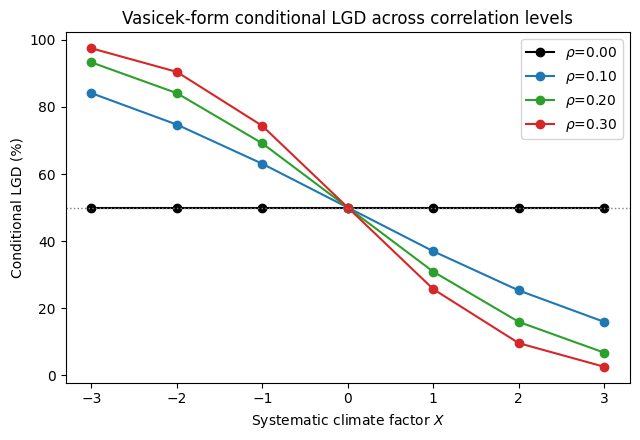

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
colors = [color_black, color_blue, "#2ca02c", color_red]
for i, r in enumerate(rho_grid):
    ax.plot(X_climate, 100 * LGD_climate_grid[i, :], "o-", color=colors[i], linewidth=1.5, label=f"$\\rho$={r:.2f}")
ax.axhline(50, linestyle=":", color="gray", linewidth=1)
ax.set_xlabel("Systematic climate factor $X$")
ax.set_ylabel("Conditional LGD (%)")
ax.set_title("Vasicek-form conditional LGD across correlation levels")
ax.legend()
plt.tight_layout()
plt.show()